# Exploratory Data Analysis for "Don't Patronize Me!" Dataset

In [307]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)
sns.set_style("darkgrid")
data = pd.read_csv("data/dontpatronizeme_pcl.tsv", sep='\t', header=None, names=["par_id", "art_id", "keyword", "country_code", "text", "label"])
# data = pd.read_csv("task4_test.tsv", sep='\t', header=None)
print("data shape : ", data.shape)

data shape :  (10469, 6)
test shape :  (2094, 2)
train shape :  (8375, 2)


## 1. Data Loading and Initial Inspection

In [308]:
data.head()

,par_id,art_id,keyword,country_code,text,label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0


In [309]:
data.describe(include="all")

,par_id,art_id,keyword,country_code,text,label
count,10469.000000,10469,10469,10469,10468,10469.000000
unique,NaN,10093,10,20,10468,NaN
top,NaN,@@17361342,migrant,za,"We 're living in times of absolute insanity , ...",NaN
freq,NaN,9,1089,549,1,NaN
mean,5235.000000,NaN,NaN,NaN,NaN,0.398605
std,3022.284318,NaN,NaN,NaN,NaN,0.988935
min,1.000000,NaN,NaN,NaN,NaN,0.000000
25%,2618.000000,NaN,NaN,NaN,NaN,0.000000
50%,5235.000000,NaN,NaN,NaN,NaN,0.000000
75%,7852.000000,NaN,NaN,NaN,NaN,0.000000


<Axes: title={'center': 'Label Distribution'}>

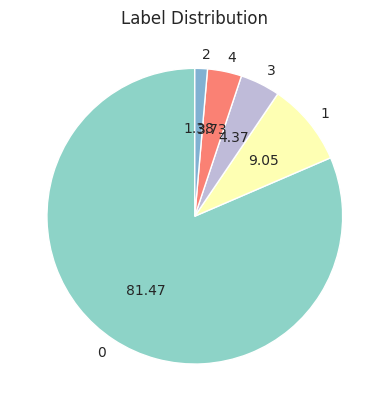

In [311]:
data.label.value_counts().plot(kind='pie', autopct='%.2f', startangle=90, title='Label Distribution', legend=False)

The dataset is significantly imbalanced and most of the labeled examples are not PCL - mainly being of label 0:
- No PCL - Label 0 + 1: 81.47% + 9.05% = 90.52%
- PCL - Labels 2-4: 18.48%

Therefore, we need to consider the impact of this on training of the data. For example: this could be why they use F1 scoring in the original paper. We can also consider doing things like oversampling the PCL examples, or over weighting / SMOTE.

---
## 2. Label Distribution Analysis

<Figure size 1200x600 with 0 Axes>

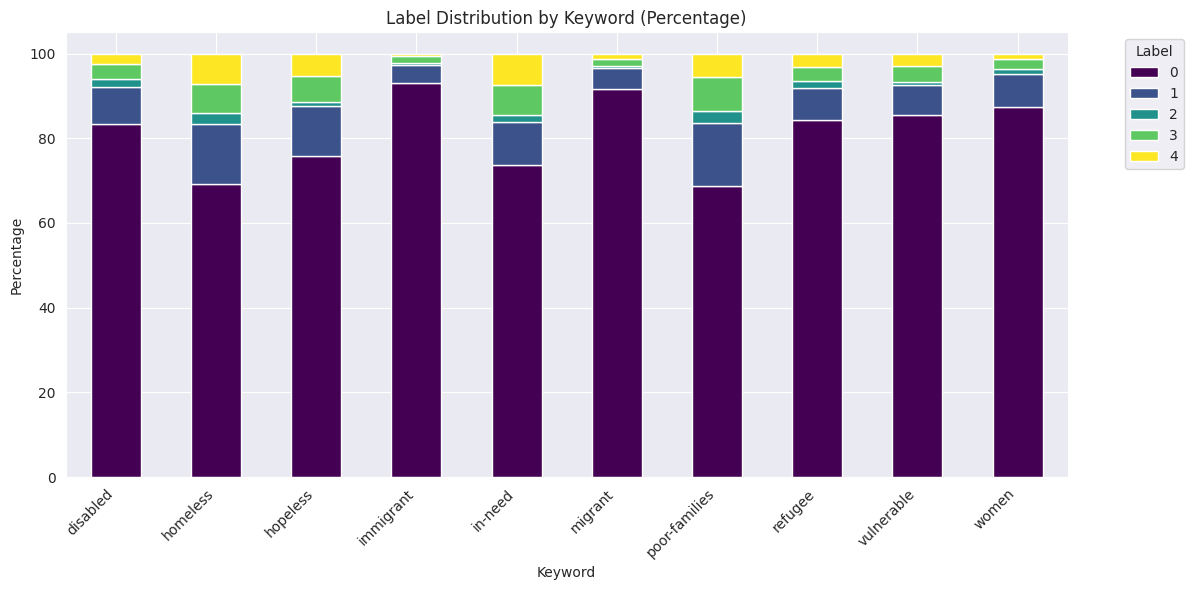

In [312]:
# Label distribution by keyword
keyword_label_crosstab = pd.crosstab(data['keyword'], data['label'], normalize='index') * 100

plt.figure(figsize=(12, 6))
keyword_label_crosstab.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Label Distribution by Keyword (Percentage)')
plt.xlabel('Keyword')
plt.ylabel('Percentage')
plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Keyword-Label Association

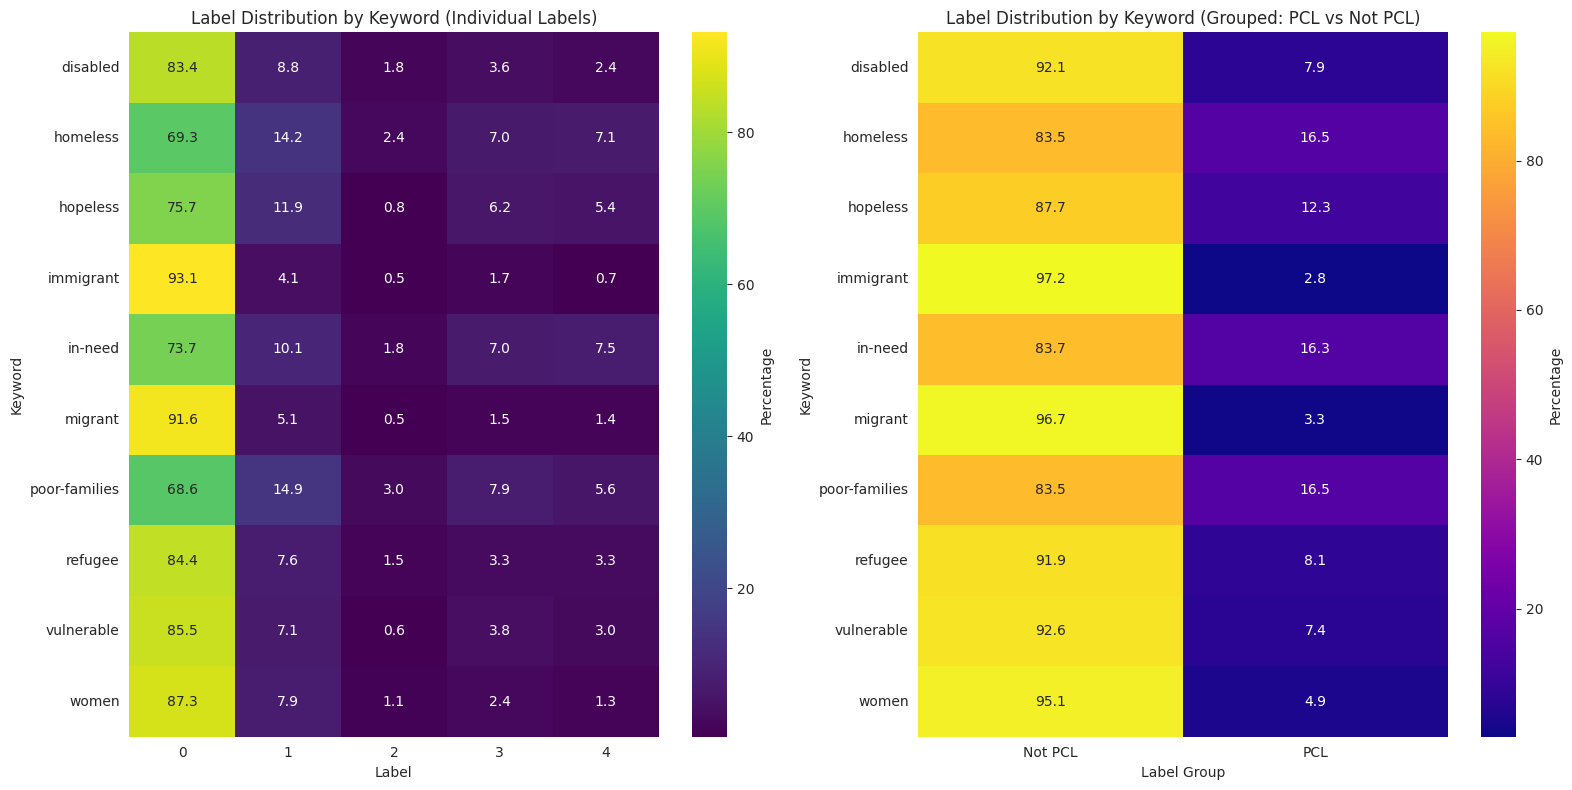

In [313]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Individual labels heatmap
sns.heatmap(keyword_label_crosstab, annot=True, fmt='.1f', cmap='viridis',
            cbar_kws={'label': 'Percentage'}, ax=axes[0])
axes[0].set_title('Label Distribution by Keyword (Individual Labels)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Keyword')

# Grouped labels heatmap
keyword_label_crosstab_grouped = pd.DataFrame({
    'Not PCL': keyword_label_crosstab[[0, 1]].sum(axis=1),
    'PCL': keyword_label_crosstab[[2, 3, 4]].sum(axis=1)
})
sns.heatmap(keyword_label_crosstab_grouped, annot=True, fmt='.1f', cmap='plasma',
            cbar_kws={'label': 'Percentage'}, ax=axes[1])
axes[1].set_title('Label Distribution by Keyword (Grouped: PCL vs Not PCL)')
axes[1].set_xlabel('Label Group')
axes[1].set_ylabel('Keyword')

plt.tight_layout()
plt.show()

The above heatmaps show that certain keywords are more prevalent in PCL contexts: "poor families" (16.5% PCL) and "homeless" (16.5% PCL), "in-need" (16.3% PCL). Whereas keywords like "immigrant" (2.5% PCL) and "migrant" (3.3% PCL) are not so prevalent.
Therefore, according to the dataset, some keywords are highly associated with PCL contexts.

However, keyword alone may not be enough to distinguish PCL from non-PCL contexts. To prevent the model from simply learning these correlations, we should consider ways to reduce the impact of these. For example: occasionally masking / replacing keywords to enforce learning from context.


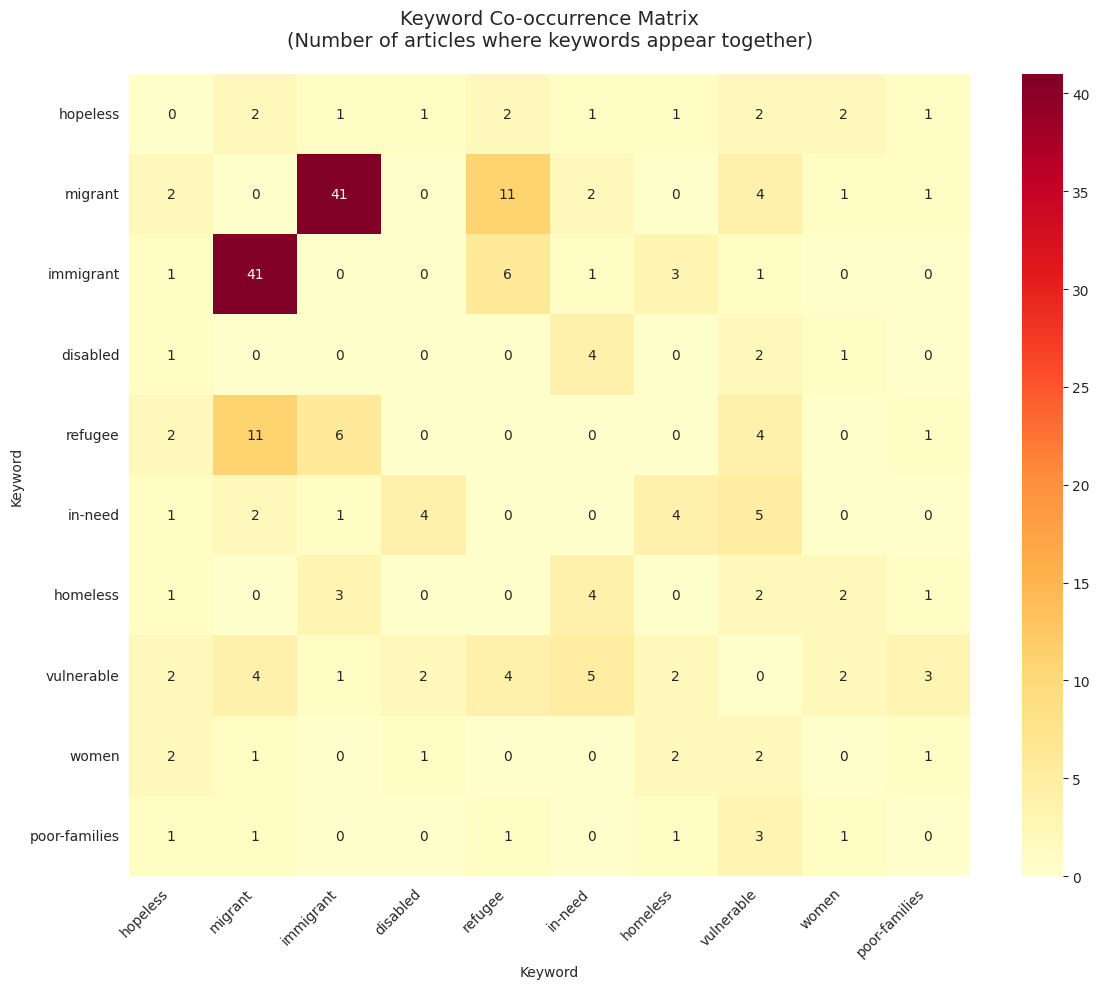

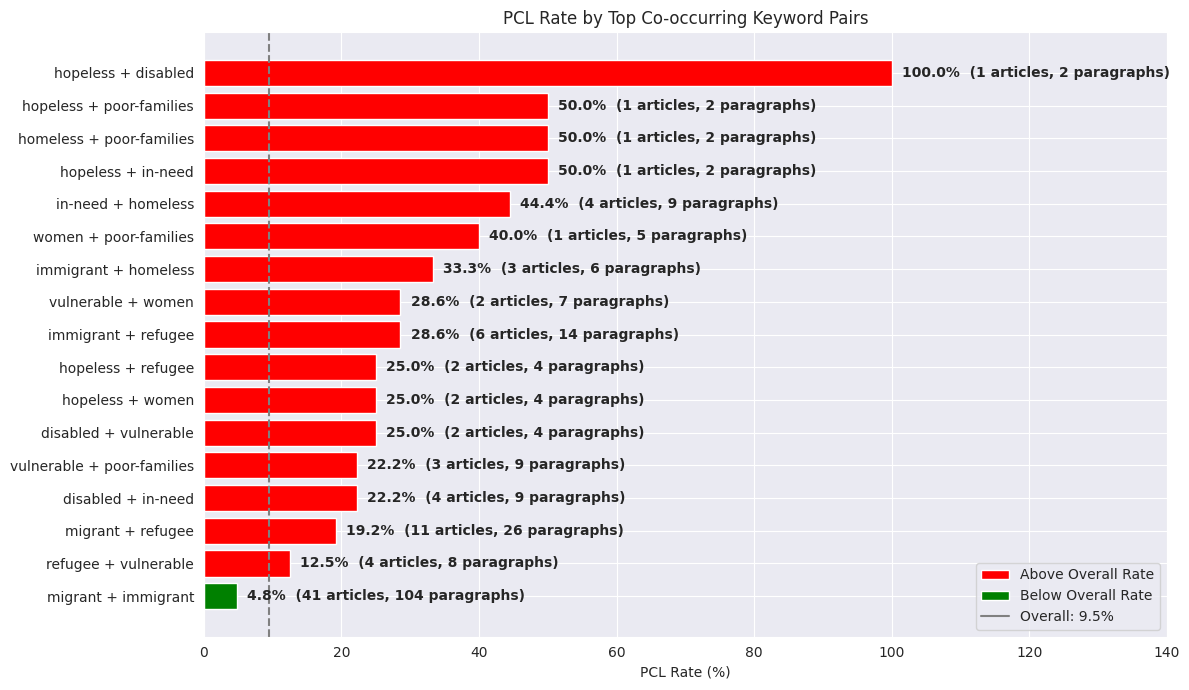

In [314]:
# Keyword Co-occurrence Analysis

keywords = data['keyword'].unique()
article_keywords = data.groupby('art_id')['keyword'].apply(list).reset_index()
cooccurrence_matrix = pd.DataFrame(0, index=keywords, columns=keywords)

for _, row in article_keywords.iterrows():
    article_kw = list(set(row['keyword']))
    for i, kw1 in enumerate(article_kw):
        for kw2 in article_kw[i:]:
            if kw1 != kw2:
                cooccurrence_matrix.loc[kw1, kw2] += 1
                cooccurrence_matrix.loc[kw2, kw1] += 1

plt.figure(figsize=(12, 10))
sns.heatmap(cooccurrence_matrix, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Keyword Co-occurrence Matrix\n(Number of articles where keywords appear together)',
          fontsize=14, pad=20)
plt.xlabel('Keyword')
plt.ylabel('Keyword')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

cooccurrence_pairs = []
for i in range(len(keywords)):
    for j in range(i+1, len(keywords)):
        count = cooccurrence_matrix.iloc[i, j]
        if count > 0:
            cooccurrence_pairs.append((keywords[i], keywords[j], count))

cooccurrence_pairs.sort(key=lambda x: x[2], reverse=True)

pcl_rates_data = []
for kw1, kw2, count in cooccurrence_pairs:
    articles_with_both = article_keywords[
        article_keywords['keyword'].apply(lambda x: kw1 in x and kw2 in x)
    ]['art_id'].values
    texts_with_both = data[data['art_id'].isin(articles_with_both)]
    pcl_rate = (texts_with_both['label'] > 1).mean() * 100

    if pcl_rate == 0: continue

    pcl_rates_data.append({
        'pair': f"{kw1} + {kw2}",
        'pcl_rate': pcl_rate,
        'article_count': count,
        'paragraph_count': len(texts_with_both)
    })

pcl_rates_df = pd.DataFrame(pcl_rates_data)
pcl_rates_df = pcl_rates_df.sort_values('pcl_rate', ascending=True)
overall_pcl_rate = (data['label'] > 1).mean() * 100

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['red' if rate > overall_pcl_rate else 'green' for rate in pcl_rates_df['pcl_rate']]

bars = ax.barh(range(len(pcl_rates_df)), pcl_rates_df['pcl_rate'], color=colors)

ax.set_yticks(range(len(pcl_rates_df)))
ax.set_yticklabels(pcl_rates_df['pair'])
ax.set_xlabel('PCL Rate (%)')
ax.set_title('PCL Rate by Co-occurring Keyword Pairs')

ax.axvline(x=overall_pcl_rate, color='grey', linestyle='--')

for i, (bar, row) in enumerate(zip(bars, pcl_rates_df.itertuples())):
    width = bar.get_width()
    label = f'{row.pcl_rate:.1f}%  ({row.article_count} articles, {row.paragraph_count} paragraphs)'
    ax.text(width + 1.5, bar.get_y() + bar.get_height()/2.,
            label,
            ha='left', va='center', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

ax.legend(handles=[
    Patch(facecolor='red', label='Above Overall Rate'),
    Patch(facecolor='green', label='Below Overall Rate'),
    Line2D([0], [0], color='grey', label=f'Overall: {overall_pcl_rate:.1f}%')
], loc='lower right')

ax.set_xlim(0, max(pcl_rates_df['pcl_rate']) * 1.4)

plt.tight_layout()
plt.show()

Here we look at how multiple keywords affect PCL rate in the dataset, and we can see that some keyword pairs occur more frequently than others. But there are few cases where there are multiple keywords, therefore it is hard to come to a conclusion on whether they affect PCL rate.

---
## 4. Keyword Co-occurrence Analysis

        text_length    word_count
count  10469.000000  10469.000000
mean     266.509791     48.422485
std      159.878916     29.091331
min        0.000000      0.000000
25%      168.000000     30.000000
50%      232.000000     42.000000
75%      329.000000     60.000000
max     5493.000000    909.000000


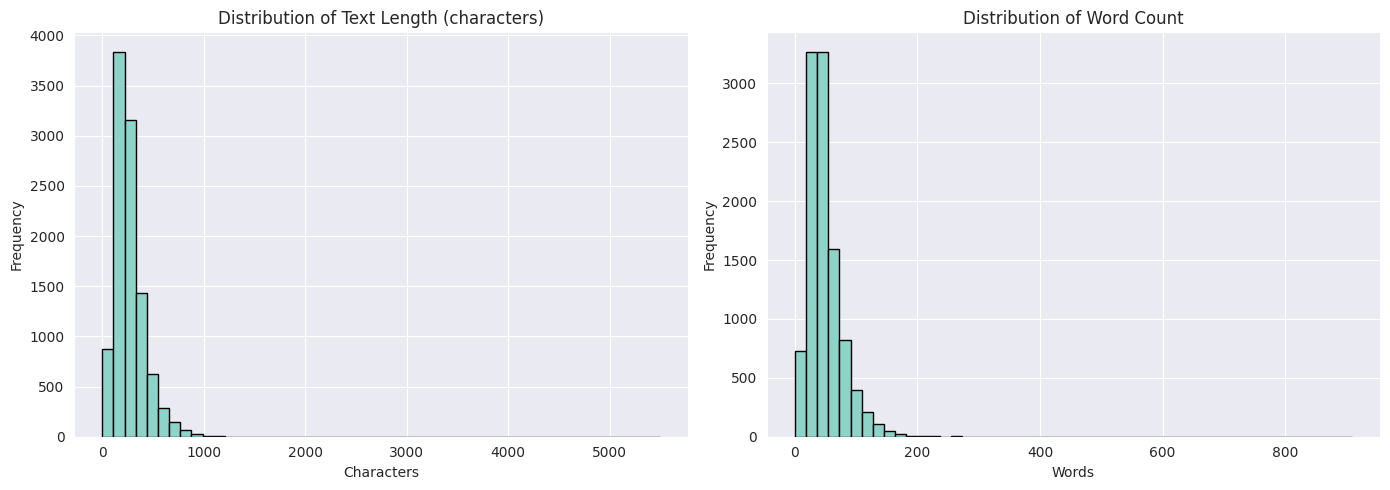

In [315]:
data['text_length'] = data['text'].fillna('').apply(len)
data['word_count'] = data['text'].fillna('').apply(lambda x: len(str(x).split()))

text_stats = data[['text_length', 'word_count']].describe()
print(text_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data['text_length'].hist(bins=50, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribution of Text Length (characters)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

data['word_count'].hist(bins=50, ax=axes[1], edgecolor='black')
axes[1].set_title('Distribution of Word Count')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

---
## 5. Text Length Statistics

      text_length                          word_count                       
             mean median     std min   max       mean median    std min  max
label                                                                       
0          262.31  229.0  156.69   0  5493      47.42   41.0  28.37   0  909
1          282.82  245.0  168.66  16  2336      52.02   45.0  30.54   2  419
2          269.27  244.0  171.34  44  1339      49.10   43.0  31.27   6  252
3          277.38  244.5  138.43  34   886      51.56   45.0  25.60   7  152
4          304.95  263.0  210.55  42  2776      57.70   50.0  39.71   7  512


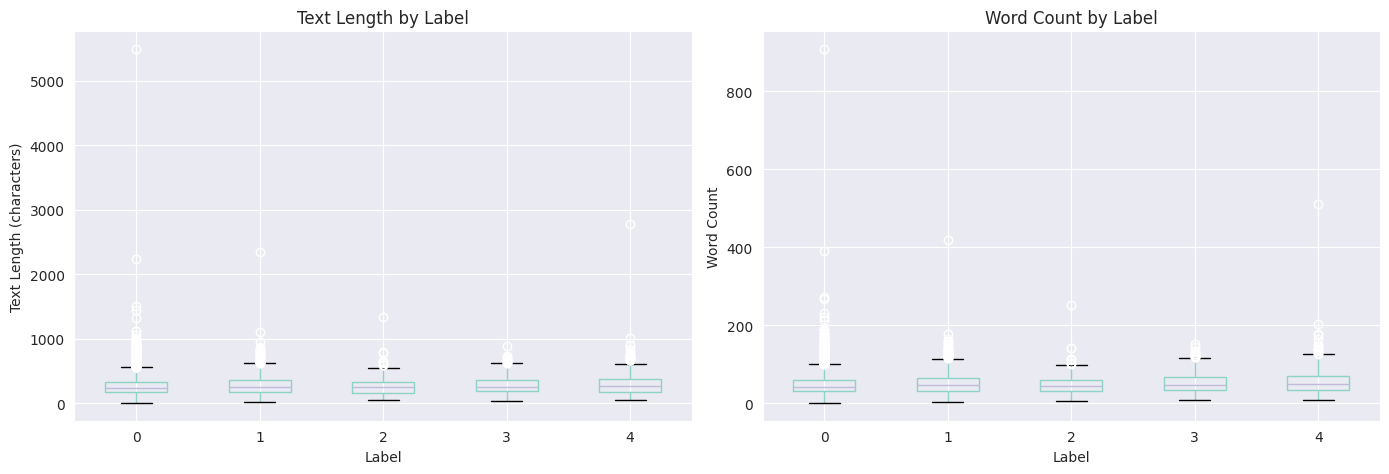

In [316]:
label_text_stats = data.groupby('label').agg({
    'text_length': ['mean', 'median', 'std', 'min', 'max'],
    'word_count': ['mean', 'median', 'std', 'min', 'max']
}).round(2)

print(label_text_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Text length by label
data.boxplot(column='text_length', by='label', ax=axes[0])
axes[0].set_title('Text Length by Label')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Text Length (characters)')
plt.suptitle('')

# Word count by label
data.boxplot(column='word_count', by='label', ax=axes[1])
axes[1].set_title('Word Count by Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.show()

From the above plots, we can see that regardless of label, text length and word count are generally similar. Therefore, there is a low chance that the model will learn to distinguish PCL from non-PCL contexts based on these features alone, so there is not much need to consider this.

---
## 6. N-gram Frequency Analysis

In [323]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer = CountVectorizer(ngram_range=(2, 3), lowercase=True)
X = vectorizer.fit_transform(data['text'].fillna(''))

feature_names = vectorizer.get_feature_names_out()
total_counts = X.sum(axis=0).A1

pcl_mask = (data['label'] > 1).to_numpy()
X_pcl = X[pcl_mask]
X_non_pcl = X[~pcl_mask]

pd.DataFrame({
    'n-gram': feature_names,
    'PCL Count': X_pcl.sum(axis=0).A1,
    'Non-PCL Count': X_non_pcl.sum(axis=0).A1,
    'Total': total_counts
}).sort_values('Total', ascending=False).head(40)


,Bigram,PCL Count,Non-PCL Count,Total
339276,of the,286,2421,2707
242889,in the,220,2203,2423
516830,to the,146,1168,1314
240591,in need,184,841,1025
376103,poor families,150,771,921
180987,for the,123,749,872
347460,on the,83,728,811
506719,to be,94,646,740
43778,and the,77,653,730
62758,at the,59,593,652


In [324]:
vectorizer = CountVectorizer(ngram_range=(4, 4), lowercase=True)
X = vectorizer.fit_transform(data['text'].fillna(''))

feature_names = vectorizer.get_feature_names_out()
total_counts = X.sum(axis=0).A1

pcl_mask = (data['label'] > 1).to_numpy()
X_pcl = X[pcl_mask]
X_non_pcl = X[~pcl_mask]

pd.DataFrame({
    'n-gram': feature_names,
    'PCL Count': X_pcl.sum(axis=0).A1,
    'Non-PCL Count': X_non_pcl.sum(axis=0).A1,
    'Total': total_counts
}).sort_values('Total', ascending=False).head(40)


,Bigram,PCL Count,Non-PCL Count,Total
34761,are in need of,4,89,93
69194,children from poor families,15,41,56
169455,is in need of,5,50,55
353356,to those in need,21,30,51
161073,in the united states,1,40,41
170336,is one of the,2,35,37
148423,hundreds of thousands of,10,27,37
42922,at the same time,3,33,36
353067,to the united states,3,30,33
117011,for those in need,6,24,30


Here we can see that amongst the top 40 most frequent bigrams/trigrams, a majority of them are more filler words and there are very few common phrases / terminologies that could suggest PCL. There are some phrases like "in need" (17.95% PCL), "poor families" (16.29% PCL), "illegal immigrants" (~1% PCL) that are fairly common, and may identify patterns to detect PCL. However, when we consider 4-grams (non filler / generic phrases), we see a more reasonable set of n-grams, that may represent a correlation to PCL.
Therefore, it is more important to consider longer n-grams, as these better capture the underlying meaning / context of the text and will be more beneficial to classify PCL.

---

## 7. Stop Word Density Analysis

        mean  median   std
label                     
0      36.58   36.78  8.18
1      38.68   39.02  7.71
2      37.45   37.99  8.42
3      39.59   40.00  7.49
4      40.52   41.05  7.90


<Figure size 1200x600 with 0 Axes>

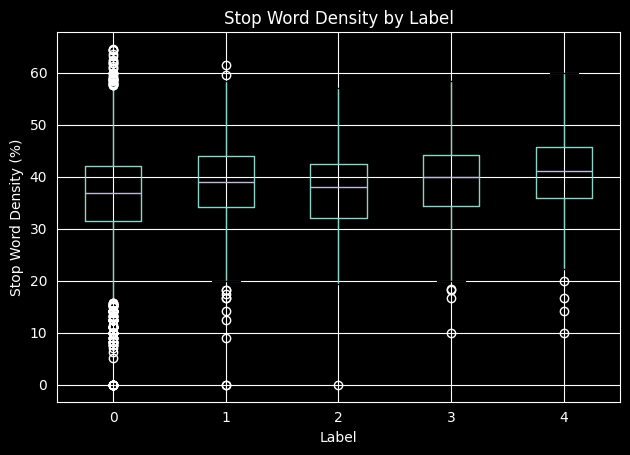

In [331]:
# Stop word density - density of filler words
from nltk.corpus import stopwords
import nltk

try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))


def calculate_stop_word_density(text):
    if pd.isna(text) or text == '':
        return 0
    words = text.lower().split()
    if len(words) == 0:
        return 0
    stop_word_count = sum(1 for word in words if word in stop_words)
    return (stop_word_count / len(words)) * 100

data['stop_word_density'] = data['text'].apply(calculate_stop_word_density)

stop_word_stats = data.groupby('label')['stop_word_density'].agg(['mean', 'median', 'std']).round(2)
print(stop_word_stats)

plt.figure(figsize=(12, 6))
data.boxplot(column='stop_word_density', by='label')
plt.title('Stop Word Density by Label')
plt.xlabel('Label')
plt.ylabel('Stop Word Density (%)')
plt.suptitle('')
plt.tight_layout()
plt.show()


Above, we can see that across the labels the stop word density is similar (range of ~4%). Therefore, all the articles are all fairly natural and there is not a clear pattern to distinguish PCL articles. There is also not an excessive number of stop words on average, and therefore we do not need to do any cleaning to remove stop words. The overall range of stop words is also fairly decent (20% to 60%), therefore the dataset encodes a range of types of text (books, news articles, etc), therefore we have a good range of data to learn from.

## 8. UMAP Embedding Visualization

In [319]:
# UMAP Embedding Visualization: PCL vs Non-PCL
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
import umap

tfidf = TfidfVectorizer(max_features=500, min_df=5, max_df=0.7, stop_words='english')
embeddings = tfidf.fit_transform(data['text'].fillna(''))

data_len = len(data)
sample_size = min(5000, data_len)
sample_idx = np.random.choice(data_len, sample_size, replace=False)
embeddings_sample = embeddings[sample_idx].toarray()
pcl_mask_sample = pcl_mask[sample_idx]

umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embeddings_umap = umap_model.fit_transform(embeddings_sample)

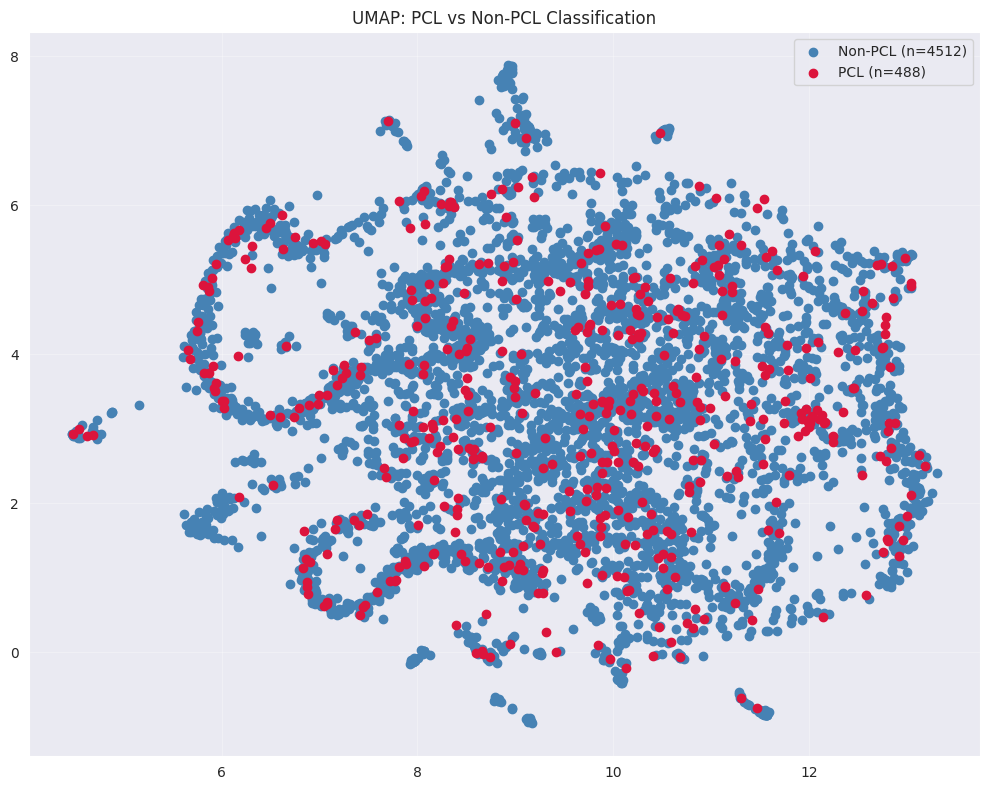

Total samples: 5000
Non-PCL: 4512 (90.2%)
PCL: 488 (9.8%)
Silhouette Score: -0.0076


In [320]:
plt.figure(figsize=(10, 8))

for label_val, color, name in [(False, 'steelblue', 'Non-PCL'), (True, 'crimson', 'PCL')]:
    mask = pcl_mask_sample == label_val
    plt.scatter(embeddings_umap[mask, 0], embeddings_umap[mask, 1],
                c=color, label=f'{name} (n={mask.sum()})')

plt.title('UMAP: PCL vs Non-PCL Classification')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total samples: {len(embeddings_sample)}")
print(f"Non-PCL: {(~pcl_mask_sample).sum()} ({(~pcl_mask_sample).sum() / len(pcl_mask_sample) * 100:.1f}%)")
print(f"PCL: {pcl_mask_sample.sum()} ({pcl_mask_sample.sum() / len(pcl_mask_sample) * 100:.1f}%)")
print(f"Silhouette Score: {silhouette_score(embeddings_umap, pcl_mask_sample) :.4f}")


Here from the UMAP visualization, we can see that there is no clear clustering between PCL and non_

**Analysis**:
- **Silhouette Score: -0.008** (near-zero indicates significant overlap)
- PCL and Non-PCL texts **not well-separated** in TF-IDF semantic space
- Some PCL clusters visible but heavily intermixed with Non-PCL
- Class imbalance (90% Non-PCL) dominates the visualization

**Impact**:
1. **TF-IDF alone insufficient** for PCL detection - need contextual embeddings
2. Consider **BERT/RoBERTa** for semantic understanding beyond bag-of-words
3. **Syntactic features** (dependency parsing, POS patterns) likely crucial
4. This confirms PCL is **subtle** - requires deeper linguistic analysis than lexical features
5. Motivates **ensemble approach**: combine lexical, syntactic, and contextual features